In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

### 数据导入

In [3]:
df1=pd.read_excel(r"C:\Users\27968\Desktop\学习\计算机\机器学习与数据挖掘\2024期末大作业\2024期末大作业\缺陷检测.xlsx")

In [163]:
df=df1

In [164]:
df.head(3)

,时间X1,缺陷累计产生数量X2,特征X3,特征X4,特征X5,特征X6,特征X7,特征X8,特征X9,缺陷检测质量风险 Y,shift_id
0,2050-12-31 06:43:39,0,40,43,0,0,0,0,0,无质量隐患,1
1,2050-12-31 06:44:09,0,120,146,0,0,0,0,0,NaN,1
2,2050-12-31 06:44:39,0,120,146,0,0,0,0,0,NaN,1


In [165]:
df['缺陷检测质量风险 Y'].value_counts()

缺陷检测质量风险 Y
无质量隐患    97
有质量隐患    44
Name: count, dtype: int64

### 数据预处理

In [166]:
def generate_shift_ids(series):
    # 创建一个新的ID列，初始值为0
    ids = pd.Series(0, index=series.index)
    current_id = 1
    last_valid_idx = None
    
    # 遍历series中的每个值和它的索引
    for idx in series.index:
        if pd.notna(series[idx]):  # 如果是非缺失值
            if last_valid_idx is not None:  # 如果不是第一个非缺失值
                # 将两个非缺失值之间的所有行赋予相同的ID
                ids.loc[last_valid_idx:idx] = current_id
                current_id += 1
            last_valid_idx = idx
    
    # 处理最后一段
    if last_valid_idx is not None:
        ids.loc[last_valid_idx:] = current_id
        
    return ids

# 使用示例：
df['shift_id'] = generate_shift_ids(df['缺陷检测质量风险 Y'])

In [167]:
df['shift_id'].max() # 有多少个不同的ID

141

In [168]:
def f(group):
    x1 = group.iloc[[0]]
    x2 = group[group['缺陷累计产生数量X2'] != group['缺陷累计产生数量X2'].shift()]
    x1 = pd.concat([x1, x2])
    return x1

# 按班次分组并处理
df_new = df.groupby('shift_id').apply(f)
#去除重复值
df_new = df_new.drop_duplicates()

C:\Users\27968\AppData\Local\Temp\ipykernel_26368\70679916.py:8: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [169]:
df_new.head(3)

时间X1  缺陷累计产生数量X2   特征X3   特征X4  特征X5  特征X6  特征X7  \
shift_id                                                                       
1        0   2050-12-31 06:43:39           0     40     43     0     0     0   
         119 2050-12-31 07:43:11           3  13150  13267     0     0     4   
         226 2050-12-31 08:36:42           6  31190  31283     3     0     5   

              特征X8  特征X9 缺陷检测质量风险 Y  shift_id  
shift_id                                       
1        0       0     0      无质量隐患         1  
         119     2    21        NaN         1  
         226     2    24        NaN         1

In [170]:
#删除现有的索引
df_new.reset_index(drop=True, inplace=True)
shift_counts = df_new.groupby('shift_id').size()

In [171]:
df_new

,时间X1,缺陷累计产生数量X2,特征X3,特征X4,特征X5,特征X6,特征X7,特征X8,特征X9,缺陷检测质量风险 Y,shift_id
0,2050-12-31 06:43:39,0,40,43,0,0,0,0,0,无质量隐患,1
1,2050-12-31 07:43:11,3,13150,13267,0,0,4,2,21,NaN,1
2,2050-12-31 08:36:42,6,31190,31283,3,0,5,2,24,NaN,1
3,2050-12-31 09:31:44,9,49260,49313,3,0,13,5,47,NaN,1
4,2050-12-31 10:31:46,12,67570,67493,3,0,13,5,61,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
1179,2051-03-30 22:52:56,27,117320,117376,4,0,48,1,169,NaN,141
1180,2051-03-30 23:04:26,30,121250,121147,6,0,58,4,178,NaN,141
1181,2051-03-31 00:01:28,33,139410,139254,6,0,66,4,197,NaN,141
1182,2051-03-31 00:44:29,36,153650,153522,7,0,87,6,214,NaN,141


In [172]:
print(shift_counts)
print(f'最大的班次为：{shift_counts.max()}')  # 最大的班次有多少行


shift_id
1      10
2       6
3       4
4       6
5       2
       ..
137     2
138    11
139    15
140    14
141    14
Length: 141, dtype: int64
最大的班次为：23


In [173]:
fig = px.histogram(shift_counts, title='频数分布直方图')
fig.show()

### 数据准备

In [174]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils import shuffle
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


In [175]:
# 1. 处理缺陷检测质量风险标签
# 按shift_id分组填充缺失值
df_new['缺陷检测质量风险 Y'] = df_new.groupby('shift_id')['缺陷检测质量风险 Y'].transform(lambda x: x.fillna(x.iloc[0]))

# 将文本标签转换为数值(0,1)
df_new['缺陷检测质量风险 Y'] = df_new['缺陷检测质量风险 Y'].map({
    '无质量隐患': 0, 
    '有质量隐患': 1
}).astype(int)

# 2. 准备第一套数据（不padding）
data = df_new.drop(columns=['shift_id', '时间X1'])
X = data.drop(columns=['缺陷检测质量风险 Y']).values
Y = data['缺陷检测质量风险 Y'].values

# 3. 特征标准化
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# 转换第一套数据为tensor
X_no_padding = torch.FloatTensor(X_normalized)
Y_no_padding = torch.FloatTensor(Y)

# 4. 准备第二套数据（padding）
max_len = df_new.groupby('shift_id').size().max()
X_grouped = []
Y_grouped = []

for _, group in df_new.groupby('shift_id'):
    # 处理X
    group_X = scaler.transform(group.drop(columns=['shift_id', '时间X1', '缺陷检测质量风险 Y']).values)
    group_Y = group['缺陷检测质量风险 Y'].values
    
    # 如果需要padding
    if len(group_X) < max_len:
        padding_rows = max_len - len(group_X)
        # X补0
        X_pad = np.pad(group_X, ((0, padding_rows), (0, 0)), mode='constant')
        # Y重复最后一个值
        Y_pad = np.pad(group_Y, (0, padding_rows), mode='edge')
    else:
        X_pad = group_X[:max_len]
        Y_pad = group_Y[:max_len]
    
    X_grouped.append(X_pad)
    Y_grouped.append(Y_pad)

# 将所有组合并
X_padded = np.vstack(X_grouped)
Y_padded = np.hstack(Y_grouped)

# 转换第二套数据为tensor
X_padded_tensor = torch.FloatTensor(X_padded)
Y_padded_tensor = torch.FloatTensor(Y_padded)

# 打印形状查看结果
print("Without padding:", X_no_padding.shape, Y_no_padding.shape)
print("With padding:", X_padded_tensor.shape, Y_padded_tensor.shape)

Without padding: torch.Size([1184, 8]) torch.Size([1184])
With padding: torch.Size([3243, 8]) torch.Size([3243])


### CNN+LSTM

In [201]:
import numpy as np
import torch

# 假设 X_padded 是形状 (3243, 9)，Y_padded 是 (3243, 1)
# 你的样本数量是 141，每个样本有 23 个时间步
N_samples = 141  # 样本数量
T = 23  # 每个样本的时间步数
features = 8  # 每个时间步的特征数

# 1. 重塑 X 数据：从 (3243, 9) 转换为 (141, 23, 9)
X_padded_reshaped = X_padded.reshape(N_samples, T, features)

# 2. 重塑 Y 数据：从 (3243, 1) 转换为 (141, 23, 1)
# 每个样本有 23 个时间步，且所有时间步共享一个标签
Y_padded_reshaped = Y_padded.reshape(N_samples, T, 1)

# 3. 转换为 PyTorch 张量
X_train_tensor = torch.tensor(X_padded_reshaped, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_padded_reshaped, dtype=torch.float32)

# 打印形状以验证
print(f"X tensor shape: {X_train_tensor.shape}")  # 应该是 (141, 23, 9)
print(f"Y tensor shape: {Y_train_tensor.shape}")  # 应该是 (141, 23, 1)

# 4. 拆分训练集和测试集
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_train_tensor, Y_train_tensor, test_size=0.2, random_state=42
)

# 5. 创建 DataLoader
from torch.utils.data import DataLoader, TensorDataset

train_data = TensorDataset(X_train, Y_train)
test_data = TensorDataset(X_test, Y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 数据验证
for batch_x, batch_y in train_loader:
    print(f"Batch X shape: {batch_x.shape}")  # 应该是 (batch_size, 23, 9)
    print(f"Batch Y shape: {batch_y.shape}")  # 应该是 (batch_size, 23, 1)
    break


X tensor shape: torch.Size([141, 23, 8])
Y tensor shape: torch.Size([141, 23, 1])
Batch X shape: torch.Size([32, 23, 8])
Batch Y shape: torch.Size([32, 23, 1])


In [209]:
# 4. 定义卷积 LSTM 网络
class ConvLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ConvLSTM, self).__init__()
        self.conv1 = nn.Conv1d(input_size, 64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(64, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.conv1(x)  # Conv1D
        x, _ = self.lstm(x.permute(0, 2, 1))  # LSTM
        x = self.fc(x)  # 输出每个时间步的分类结果
        return x

# 5. 初始化模型、损失函数和优化器
model = ConvLSTM(input_size=8, hidden_size=128, output_size=1)
criterion = nn.BCEWithLogitsLoss()  # 二分类任务使用 BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters(), lr=0.001)
# 训练模型
epochs = 24
train_losses = []
val_losses = []

In [214]:
from sklearn.metrics import classification_report
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        X_batch = X_batch.permute(0, 2, 1)  # 转换为 [batch_size, channels, time_steps]
        output = model(X_batch).view(-1, 2)  # 展平输出维度为 [batch_size * time_steps, 2]
        Y_batch = Y_batch.view(-1)  # 展平标签

        loss = criterion(output, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # 验证过程
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            X_batch = X_batch.permute(0, 2, 1)
            output = model(X_batch).view(-1, 2)
            Y_batch = Y_batch.view(-1)

            loss = criterion(output, Y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# 测试过程
model.eval()
test_loss = 0.0
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.permute(0, 2, 1)
        output = model(X_batch).view(-1, 2)
        Y_batch = Y_batch.view(-1)

        loss = criterion(output, Y_batch)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

# 可视化训练过程
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

# 预测
model.eval()
with torch.no_grad():
    Y_pred_probs = torch.sigmoid(model(X_test_tensor.permute(0, 2, 1)))  # [batch_size, time_steps, 1]
    Y_pred_classes = (Y_pred_probs > 0.5).float()  # 阈值化结果

# 输出分类报告
Y_test_flat = Y_test_tensor.view(-1).numpy()  # 展平为一维
Y_pred_flat = Y_pred_classes.view(-1).numpy()  # 展平为一维

# 输出分类报告，显示所有指标
print(classification_report(Y_test_flat, Y_pred_flat, target_names=[f"Class {i}" for i in range(2)]))


ValueError: Target size (torch.Size([736])) must be the same as input size (torch.Size([368, 2]))

### 其他

Training fold 1
Training fold 2
Training fold 3
Training fold 4
Training fold 5
Average Accuracy: 0.7930
Average F1-Score: 0.7855
Average Sensitivity: 0.7701
Average Precision: 0.8062
Average AUC: 0.8803


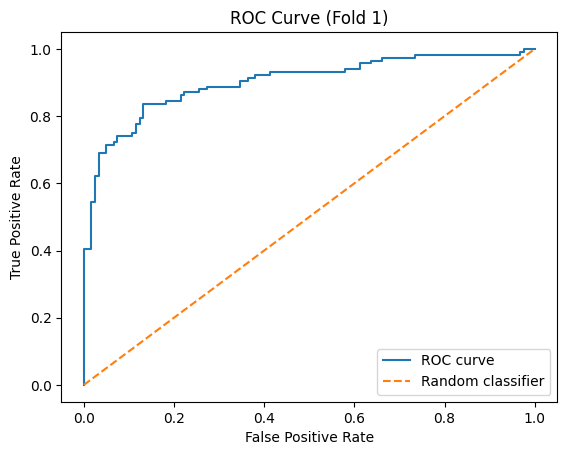

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils import shuffle
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


data = df_new.drop(columns=['shift_id'])

# 提取特征和标签
X = data.drop(columns=['缺陷检测质量风险 Y']).values  
Y = data['缺陷检测质量风险 Y'].values

# 归一化特征
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 填充到统一长度
max_len = 1150
X_padded = np.zeros((len(X), max_len))
X_padded[:X.shape[0], :X.shape[1]] = X

# 转换为tensor
X_tensor = torch.FloatTensor(X_padded)
Y_tensor = torch.FloatTensor(Y)

# 模型定义
class DNN(nn.Module):
    def __init__(self, input_dim):
        super(DNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

class CNN(nn.Module):
    def __init__(self, input_shape):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=5)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
        # 计算flatten后的维度
        conv1_out = input_shape - 4  # kernel_size=5
        conv2_out = conv1_out - 4
        self.fc_input_dim = 128 * conv2_out
        
        self.fc = nn.Linear(self.fc_input_dim, 64)
        self.output = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.unsqueeze(1)  # 添加channel维度
        x = self.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.relu(self.conv2(x))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        x = self.sigmoid(self.output(x))
        return x

class RNN(nn.Module):
    def __init__(self, input_size):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.unsqueeze(2)  # 添加feature维度
        output, _ = self.rnn(x)
        output = output[:, -1, :]  # 取最后一个时间步
        x = self.dropout(output)
        x = self.sigmoid(self.fc(x))
        return x

class LSTM(nn.Module):
    def __init__(self, input_size):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.unsqueeze(2)  # 添加feature维度
        output, _ = self.lstm(x)
        output = output[:, -1, :]  # 取最后一个时间步
        x = self.dropout(output)
        x = self.sigmoid(self.fc(x))
        return x

# 训练函数
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()


# 评估函数        
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    return np.array(all_preds), np.array(all_labels)

# 设置参数
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 32
epochs = 10
criterion = nn.BCELoss()

# 存储指标
accuracies = []
f1_scores = []
sensitivities = []
precisions = []
auc_scores = []
roc_curves = []

# 交叉验证
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tensor, Y_tensor)):
    print(f"Training fold {fold + 1}")
    
    # 准备数据
    X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
    Y_train, Y_test = Y_tensor[train_idx], Y_tensor[test_idx]
    
    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataset = TensorDataset(X_test, Y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # 选择模型
    model_CNN = CNN(X_train.shape[1]).to(device)  # CNN模型
    model_DNN = DNN(X_train.shape[1]).to(device)  # DNN模型
    model_RNN = RNN(1).to(device)  # RNN模型
    model_LSTM = LSTM(1).to(device)  # LSTM模型
    
    optimizer = optim.Adam(model_CNN.parameters())
    
    # 训练模型
    #我要训练每一个模型，修改下面的代码，写一个for循环     
    for epoch in range(epochs):
        train_model(model_CNN, train_loader, criterion, optimizer, device)
    
    # 评估模型
    Y_pred, Y_true = evaluate_model(model_CNN, test_loader, device)
    Y_pred_binary = (Y_pred > 0.5).astype(int)
    
    # 计算指标
    accuracy = accuracy_score(Y_true, Y_pred_binary)
    f1 = f1_score(Y_true, Y_pred_binary)
    sensitivity = recall_score(Y_true, Y_pred_binary)
    precision = precision_score(Y_true, Y_pred_binary)
    auc = roc_auc_score(Y_true, Y_pred)
    
    # 存储指标
    accuracies.append(accuracy)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    precisions.append(precision)
    auc_scores.append(auc)
    
    if fold == 0:
        fpr, tpr, _ = roc_curve(Y_true, Y_pred)
        roc_curves.append((fpr, tpr))

# 输出平均指标
print(f"Average Accuracy: {np.mean(accuracies):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f}")
print(f"Average Sensitivity: {np.mean(sensitivities):.4f}")
print(f"Average Precision: {np.mean(precisions):.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")

# 绘制ROC曲线
fpr, tpr = roc_curves[0]
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Fold 1)')
plt.legend()
plt.show()

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils import shuffle
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


data = df_new.drop(columns=['shift_id'])

# 提取特征和标签
X = data.drop(columns=['缺陷检测质量风险 Y']).values  
Y = data['缺陷检测质量风险 Y'].values
#转化为张量
X_tensor = torch.FloatTensor(X)
Y_tensor = torch.FloatTensor(Y)

In [27]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 填充班次数据函数
def fill_shift(group):
    group_len = len(group)
    if group_len < max_len:
        fill_len = max_len - group_len
        fill_data = np.repeat(group.iloc[-1].values.reshape(1, -1), fill_len, axis=0)
        fill_df = pd.DataFrame(fill_data, columns=group.columns)
        return pd.concat([group, fill_df])
    else:
        return group

# 预处理数据函数
def preprocess_data(data):
    n_samples = len(data)  # 样本数
    n_timesteps = data.shape[1] - 2  # 假设 'Y' 和 'id'是最后两列
    n_features = 10      # 每个时间步的特征数
    
    # 重塑数据为3D张量
    X = data.drop(columns=['Y', 'id']).values
    X = X.reshape(n_samples, n_timesteps, n_features)
    Y = data['Y'].values
    
    # 归一化 - 注意保持3D结构
    scaler = StandardScaler()
    X_reshaped = X.reshape(-1, X.shape[-1])
    X_scaled = scaler.fit_transform(X_reshaped)
    X_scaled = X_scaled.reshape(X.shape)
    
    return X_scaled, Y

# 模型定义：DNN、CNN、RNN、LSTM
class DNN(nn.Module):
    def __init__(self, input_dim):
        super(DNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

# 修改后的CNN模型构造
class CNN(nn.Module):
    def __init__(self, timesteps, features):
        super(CNN, self).__init__()

        # 一维卷积层：输入通道数为特征数，输出通道数为64，卷积核大小为5
        self.conv1 = nn.Conv1d(in_channels=features, out_channels=64, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        # 计算flatten后的维度
        self.fc_input_dim = self._calculate_flat_features(timesteps, features)
        self.fc = nn.Linear(self.fc_input_dim, 64)
        self.output = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def _calculate_flat_features(self, timesteps, features):
        dummy_input = torch.zeros(1, features, timesteps)  # 填充一个空输入
        x = self.conv1(dummy_input)
        x = self.conv2(x)
        x = self.flatten(x)
        return x.shape[1]  # 展平后的维度
    
    def forward(self, x):
        # x shape: [batch_size, timesteps, features]
        x = x.permute(0, 2, 1)  # 转换为 [batch_size, features, timesteps] 适配 Conv1d
        x = self.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.relu(self.conv2(x))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        x = self.sigmoid(self.output(x))
        return x

    def __init__(self, input_shape):
        super(CNN, self).__init__()
        
        # input_shape = (timesteps, features)
        timesteps, features = input_shape
        
        # 一维卷积层：输入通道数为特征数，输出通道数为64，卷积核大小为5
        self.conv1 = nn.Conv1d(in_channels=features, out_channels=64, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        # 计算flatten后的维度
        self.fc_input_dim = self._calculate_flat_features(input_shape)
        self.fc = nn.Linear(self.fc_input_dim, 64)
        self.output = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def _calculate_flat_features(self, input_shape):
        timesteps, features = input_shape
        dummy_input = torch.zeros(1, features, timesteps)  # 填充一个空输入
        x = self.conv1(dummy_input)
        x = self.conv2(x)
        x = self.flatten(x)
        return x.shape[1]  # 展平后的维度
    
    def forward(self, x):
        # x shape: [batch_size, timesteps, features]
        x = x.permute(0, 2, 1)  # 转换为 [batch_size, features, timesteps] 适配 Conv1d
        x = self.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.relu(self.conv2(x))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        x = self.sigmoid(self.output(x))
        return x

    def __init__(self, input_shape):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(input_shape[1], 64, kernel_size=5)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
        # 计算flatten后的维度
        self.fc = nn.Linear(self.calculate_flat_features(input_shape), 64)
        self.output = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
    
    def calculate_flat_features(self, input_shape):
        dummy_input = torch.zeros(1, *input_shape)
        x = self.conv1(dummy_input)
        x = self.conv2(x)
        x = self.flatten(x)
        return x.shape[1]
        
    def forward(self, x):
        x = x.permute(0, 2, 1)  # 转换为 [batch_size, features, timesteps]
        x = self.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.relu(self.conv2(x))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        x = self.sigmoid(self.output(x))
        return x

class RNN(nn.Module):
    def __init__(self, input_size):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.unsqueeze(2)  # 添加feature维度
        output, _ = self.rnn(x)
        output = output[:, -1, :]  # 取最后一个时间步
        x = self.dropout(output)
        x = self.sigmoid(self.fc(x))
        return x

class LSTM(nn.Module):
    def __init__(self, input_size):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.unsqueeze(2)  # 添加feature维度
        output, _ = self.lstm(x)
        output = output[:, -1, :]  # 取最后一个时间步
        x = self.dropout(output)
        x = self.sigmoid(self.fc(x))
        return x

# 训练函数
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()

# 评估函数
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    return np.array(all_preds), np.array(all_labels)

# 设置参数
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 32
epochs = 10
criterion = nn.BCELoss()

# 存储指标
accuracies = []
f1_scores = []
sensitivities = []
precisions = []
auc_scores = []
roc_curves = []

# 交叉验证
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 数据加载和训练/评估
for fold, (train_idx, test_idx) in enumerate(skf.split(X_tensor, Y_tensor)):
    print(f"Training fold {fold + 1}")
    
    # 准备数据
    X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
    Y_train, Y_test = Y_tensor[train_idx], Y_tensor[test_idx]
    
    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataset = TensorDataset(X_test, Y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # 选择模型
    model_choice = 'CNN'  # 可修改为 'DNN', 'RNN', 'LSTM'

# 在初始化CNN模型时，确保传入timesteps和features
    if model_choice == 'CNN':
        timesteps, features = X_train.shape[1], X_train.shape[2]  # 这里取的是X_train的正确形状
        model = CNN(timesteps, features).to(device)
    elif model_choice == 'DNN':
        model = DNN(X_train.shape[1]).to(device)
    elif model_choice == 'RNN':
        model = RNN(1).to(device)
    elif model_choice == 'LSTM':
        model = LSTM(1).to(device)
    
    optimizer = optim.Adam(model.parameters())
    
    # 训练模型
    for epoch in range(epochs):
        train_model(model, train_loader, criterion, optimizer, device)
    
    # 评估模型
    Y_pred, Y_true = evaluate_model(model, test_loader, device)
    Y_pred_binary = (Y_pred > 0.5).astype(int)
    
    # 计算指标
    accuracy = accuracy_score(Y_true, Y_pred_binary)
    f1 = f1_score(Y_true, Y_pred_binary)
    sensitivity = recall_score(Y_true, Y_pred_binary)
    precision = precision_score(Y_true, Y_pred_binary)
    auc = roc_auc_score(Y_true, Y_pred)
    
    # 存储指标
    accuracies.append(accuracy)
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    precisions.append(precision)
    auc_scores.append(auc)
    
    if fold == 0:
        fpr, tpr, _ = roc_curve(Y_true, Y_pred)
        roc_curves.append((fpr, tpr))

# 输出平均指标
print(f"Average Accuracy: {np.mean(accuracies):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f}")
print(f"Average Sensitivity: {np.mean(sensitivities):.4f}")
print(f"Average Precision: {np.mean(precisions):.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")

# 绘制ROC曲线
fpr, tpr = roc_curves[0]
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Fold 1)')
plt.legend()
plt.show()


Training fold 1


IndexError: tuple index out of range